# EDA (Exploratory Data Analysis)

## Import dependencies

In [187]:
import os
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import arabic_reshaper
from bidi.algorithm import get_display
from sklearn.preprocessing import OrdinalEncoder

from mappers import to_numeric

warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=DeprecationWarning)

## Read the dataset

In [188]:
dataset_directory = "../data"
dataset_file = "raw.csv"
dataset_path = os.path.join(dataset_directory, dataset_file)

dataset = pd.read_csv(filepath_or_buffer=dataset_path)

## Here we go!

#### Check the shape, where the (rows, columns) size:

In [189]:
dataset.shape

(7818, 26)

#### Check the features (columns) name:

In [190]:
dataset.columns.values

array(['Category Name', 'Category URL', 'Service Name', 'Service URL',
       'Offer Name', 'Offer URL', 'Offer Stars', 'Offer Raters',
       'Offer Response Time', 'Offer Buyers', 'Pending', 'Price',
       'Duration', 'Reviews', 'Available Additions', 'Additions Price',
       'Owner Name', 'Owner URL', 'Owner Verified', 'Owner Level',
       'Owner Stars', 'Owner Raters', 'Owner Completion Rate',
       'Owner Services', 'Owner Customers', 'Owner Response Time'],
      dtype=object)

#### Display the abstracted information:

In [191]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7818 entries, 0 to 7817
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Category Name          7818 non-null   object 
 1   Category URL           7818 non-null   object 
 2   Service Name           7818 non-null   object 
 3   Service URL            7818 non-null   object 
 4   Offer Name             7818 non-null   object 
 5   Offer URL              7818 non-null   object 
 6   Offer Stars            7818 non-null   float64
 7   Offer Raters           7818 non-null   int64  
 8   Offer Response Time    7818 non-null   object 
 9   Offer Buyers           7818 non-null   int64  
 10  Pending                7818 non-null   int64  
 11  Price                  7818 non-null   object 
 12  Duration               7818 non-null   object 
 13  Reviews                7818 non-null   int64  
 14  Available Additions    7818 non-null   int64  
 15  Addi

#### Calculate the statistical data of the numerical values:

In [192]:
dataset.describe()

,Offer Stars,Offer Raters,Offer Buyers,Pending,Reviews,Available Additions,Additions Price,Owner Stars,Owner Raters,Owner Services,Owner Customers
count,7818.000000,7818.000000,7818.000000,7818.000000,7818.000000,7818.000000,7818.000000,7818.000000,7818.000000,7818.000000,7818.000000
mean,3.534408,11.149271,15.952417,0.068560,6.737529,2.599002,83.218854,3.821438,37.689563,4.232029,46.795856
std,2.181576,26.254233,39.947638,0.320158,8.480813,1.800739,107.176584,1.980483,75.171396,3.444568,97.192959
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,10.000000,4.500000,1.000000,2.000000,2.000000
50%,5.000000,3.000000,4.000000,0.000000,3.000000,3.000000,45.000000,5.000000,11.000000,3.000000,14.000000
75%,5.000000,10.000000,13.000000,0.000000,10.000000,4.000000,115.000000,5.000000,41.000000,5.000000,50.000000
max,5.000000,566.000000,821.000000,7.000000,25.000000,5.000000,900.000000,5.000000,1704.000000,28.000000,2393.000000


#### Count the missing values:

In [193]:
dataset.isnull().sum()

Category Name            0
Category URL             0
Service Name             0
Service URL              0
Offer Name               0
Offer URL                0
Offer Stars              0
Offer Raters             0
Offer Response Time      0
Offer Buyers             0
Pending                  0
Price                    0
Duration                 0
Reviews                  0
Available Additions      0
Additions Price          0
Owner Name               0
Owner URL                0
Owner Verified           0
Owner Level              0
Owner Stars              0
Owner Raters             0
Owner Completion Rate    0
Owner Services           0
Owner Customers          0
Owner Response Time      0
dtype: int64

#### Count the duplicated values:

In [194]:
dataset.duplicated().sum()

np.int64(0)

#### Count the unique values:

In [195]:
dataset.nunique()

Category Name              11
Category URL               11
Service Name              274
Service URL               279
Offer Name               7707
Offer URL                7816
Offer Stars                10
Offer Raters              186
Offer Response Time       104
Offer Buyers              241
Pending                     6
Price                      10
Duration                   10
Reviews                    26
Available Additions         6
Additions Price           125
Owner Name               3774
Owner URL                5857
Owner Verified              2
Owner Level                 9
Owner Stars                 9
Owner Raters              301
Owner Completion Rate    1240
Owner Services             28
Owner Customers           353
Owner Response Time       102
dtype: int64

#### Display a few samples:

In [196]:
dataset.sample(frac=1).drop_duplicates(subset="Category Name")

,Category Name,Category URL,Service Name,Service URL,Offer Name,Offer URL,Offer Stars,Offer Raters,Offer Response Time,Offer Buyers,...,Owner Name,Owner URL,Owner Verified,Owner Level,Owner Stars,Owner Raters,Owner Completion Rate,Owner Services,Owner Customers,Owner Response Time
3907,كتابة وترجمة,https://khamsat.com/writing,كتابة طلبات المنح,https://khamsat.com/writing/grant-writing,كتابة خطابات توصية وخطاب النية بشكل احترافي,https://khamsat.com/writing/grant-writing/1289861-%D9%83%D8%AA%D8%A7%D8%A8%D8%A9-%D8%AE%D8%B7%D8%A7%D8%A8%D8%A7%D8%AA-%D8%AA%D9%88%D8%B5%D9%8A%D8%A9-%D9%88%D8%AE%D8%B7%D8%A7%D8%A8-%D8%A7%D9%84%D9%86%D9%8A%D8%A9-%D8%A8%D8%B4%D9%83%D9%84-%D8%A7%D8%AD%D8%AA%D8%B1%D8%A7%D9%81%D9%8A,5.0,105,ساعة,157,...,.Mahmoud E,https://khamsat.com/user/m_abdelsattar,True,بائع مميز,5.0,132,93.7%,11,188,3 ساعات
4468,تسويق رقمي,https://khamsat.com/marketing,جيست بوست,https://khamsat.com/marketing/guest-posts,نشر مقال جيست بوست علي موقع عرباوي التقني 3rbaway.com,https://khamsat.com/marketing/guest-posts/1883875-%D9%86%D8%B4%D8%B1-%D9%85%D9%82%D8%A7%D9%84-%D8%AC%D9%8A%D8%B3%D8%AA-%D8%A8%D9%88%D8%B3%D8%AA-%D8%B9%D9%84%D9%8A-%D9%85%D9%88%D9%82%D8%B9-%D8%B9%D8%B1%D8%A8%D8%A7%D9%88%D9%8A-%D8%A7%D9%84%D8%AA%D9%82%D9%86%D9%8A-3rbaway.com,5.0,5,4 ساعات,13,...,علي م.,https://khamsat.com/user/alimaher19,True,بائع مميز,5.0,148,98.38%,6,256,14 ساعة
1167,تصميم,https://khamsat.com/designing,عبوات وأغلفة منتجات,https://khamsat.com/designing/packaging,تصميم استكر منتجات بأشكال وأحجام مختلفه,https://khamsat.com/designing/packaging/1635452-%D8%AA%D8%B5%D9%85%D9%8A%D9%85-%D8%A7%D8%B3%D8%AA%D9%83%D8%B1-%D9%85%D9%86%D8%AA%D8%AC%D8%A7%D8%AA-%D8%A8%D8%A3%D8%B4%D9%83%D8%A7%D9%84-%D9%88%D8%A3%D8%AD%D8%AC%D8%A7%D9%85-%D9%85%D8%AE%D8%AA%D9%84%D9%81%D9%87,4.5,6,ساعة,6,...,اسامه ر.,https://khamsat.com/user/osamaalmsdahe,True,بائع مميز,4.5,73,85.89%,3,78,6 ساعات
6465,برمجة وتطوير,https://khamsat.com/programming,أخرى,https://khamsat.com/programming/ecommerce-development-services,إنشاء موقع للتجارة الإلكترونية ecommerce,https://khamsat.com/programming/ecommerce-development-services/1518199-%D8%A5%D9%86%D8%B4%D8%A7%D8%A1-%D9%85%D9%88%D9%82%D8%B9-%D9%84%D9%84%D8%AA%D8%AC%D8%A7%D8%B1%D8%A9-%D8%A7%D9%84%D8%A5%D9%84%D9%83%D8%AA%D8%B1%D9%88%D9%86%D9%8A%D8%A9-ecommerce,5.0,2,ساعة,2,...,مصطفى أ.,https://khamsat.com/user/mostafa-hassan3,True,بائع جديد,5.0,2,100.0%,2,2,13 يوم
5219,أعمال,https://khamsat.com/business,إدارة الموارد البشرية,https://khamsat.com/business/human-resources,إجراء وتصميم التوصيف الوظيفي للعاملين,https://khamsat.com/business/human-resources/2811116-%D8%A5%D8%AC%D8%B1%D8%A7%D8%A1-%D9%88%D8%AA%D8%B5%D9%85%D9%8A%D9%85-%D8%A7%D9%84%D8%AA%D9%88%D8%B5%D9%8A%D9%81-%D8%A7%D9%84%D9%88%D8%B8%D9%8A%D9%81%D9%8A-%D9%84%D9%84%D8%B9%D8%A7%D9%85%D9%84%D9%8A%D9%86,4.5,6,21 ساعة,7,...,.Mohamed H,https://khamsat.com/user/mohamed_a_ismail,True,بائع نشيط,4.5,16,100.0%,5,17,10 ساعات
2375,هندسة وعمارة,https://khamsat.com/engineering,أنظمة المياه والصرف,https://khamsat.com/engineering/plumbing-drainage-systems,تصميم شبكات الري مزارع - حدائق - مسطحات خضراء,https://khamsat.com/engineering/plumbing-drainage-systems/2737244-%D8%AA%D8%B5%D9%85%D9%8A%D9%85-%D8%B4%D8%A8%D9%83%D8%A7%D8%AA-%D8%A7%D9%84%D8%B1%D9%8A-%D9%85%D8%B2%D8%A7%D8%B1%D8%B9-%D8%AD%D8%AF%D8%A7%D8%A6%D9%82-%D9%85%D8%B3%D8%B7%D8%AD%D8%A7%D8%AA-%D8%AE%D8%B6%D8%B1%D8%A7%D8%A1,0.0,0,5 ساعات,1,...,.Amir S,https://khamsat.com/user/amirsa3id,True,بائع جديد,0.0,0,100.0%,2,1,5 ساعات
1828,صوتيات,https://khamsat.com/audio,الرد الآلي IVR,https://khamsat.com/audio/ivr,تسجيل الرد الآلي IVR لشركتك بصوت أنثوي مميز,https://khamsat.com/audio/ivr/2611173-%D8%AA%D8%B3%D8%AC%D9%8A%D9%84-%D8%A7%D9%84%D8%B1%D8%AF-%D8%A7%D9%84%D8%A2%D9%84%D9%8A-ivr-%D9%84%D8%B4%D8%B1%D9%83%D8%AA%D9%83-%D8%A8%D8%B5%D9%88%D8%AA-%D8%A3%D9%86%D8%AB%D9%88%D9%8A-%D9%85%D9%85%D9%8A%D8%B2,5.0,1,9 ساعات,1,...,سليل غ.,https://khamsat.com/user/saleel_ghaben,True,بائع مميز,4.5,48,98.55%,2,58,13 ساعة
225,فيديو وأنيميشن,https://khamsat.com/video-design,رسوم متحرك

#### Display the data distribution:

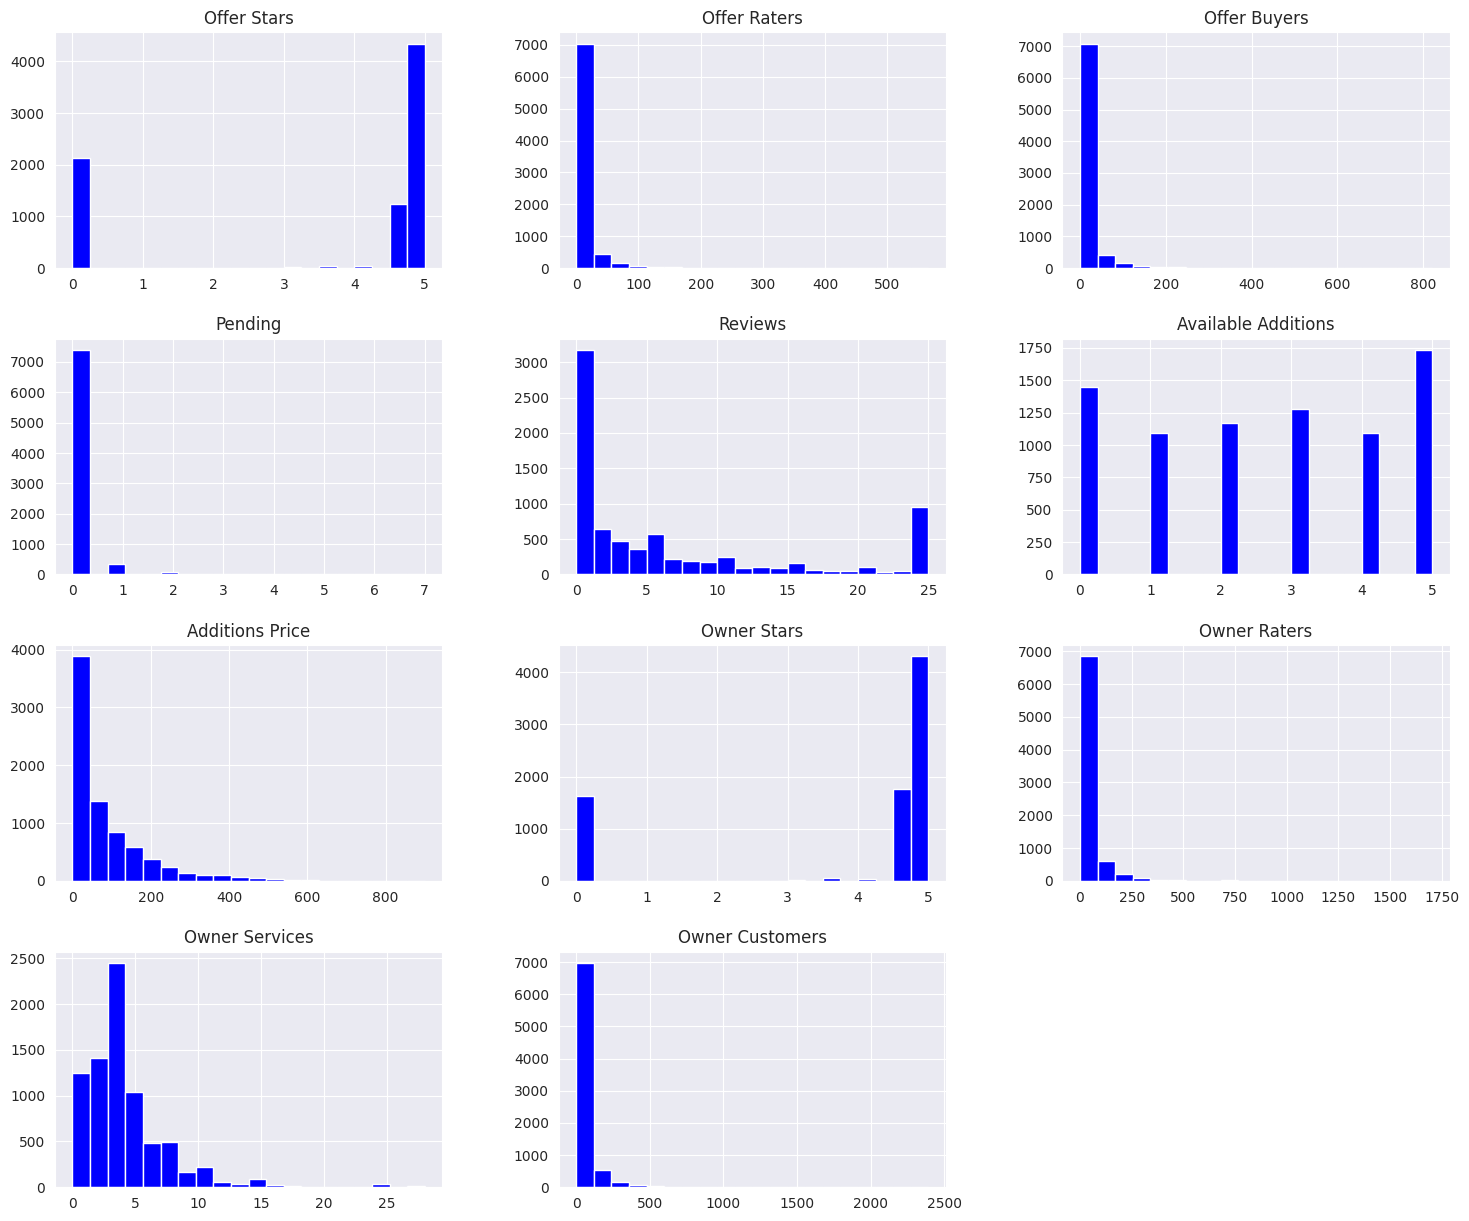

In [197]:
dataset.hist(figsize=(18, 15), bins=20, grid=True, color="blue")

plt.show()

In [ ]:
# TODO: Calculate IQR for all numerical columns, to detect the outliers

#### Display the `Duration` values distribution:

In [198]:
duration_counts = dataset["Duration"].value_counts()

print(duration_counts)

Duration
يوم واحد        4007
يومين           1884
ثلاثة أيام      1011
أسبوع            276
أربعة أيام       216
خمسة أيام        184
شهر              115
أسبوعين           70
ستة أيام          35
ثلاثة أسابيع      20
Name: count, dtype: int64


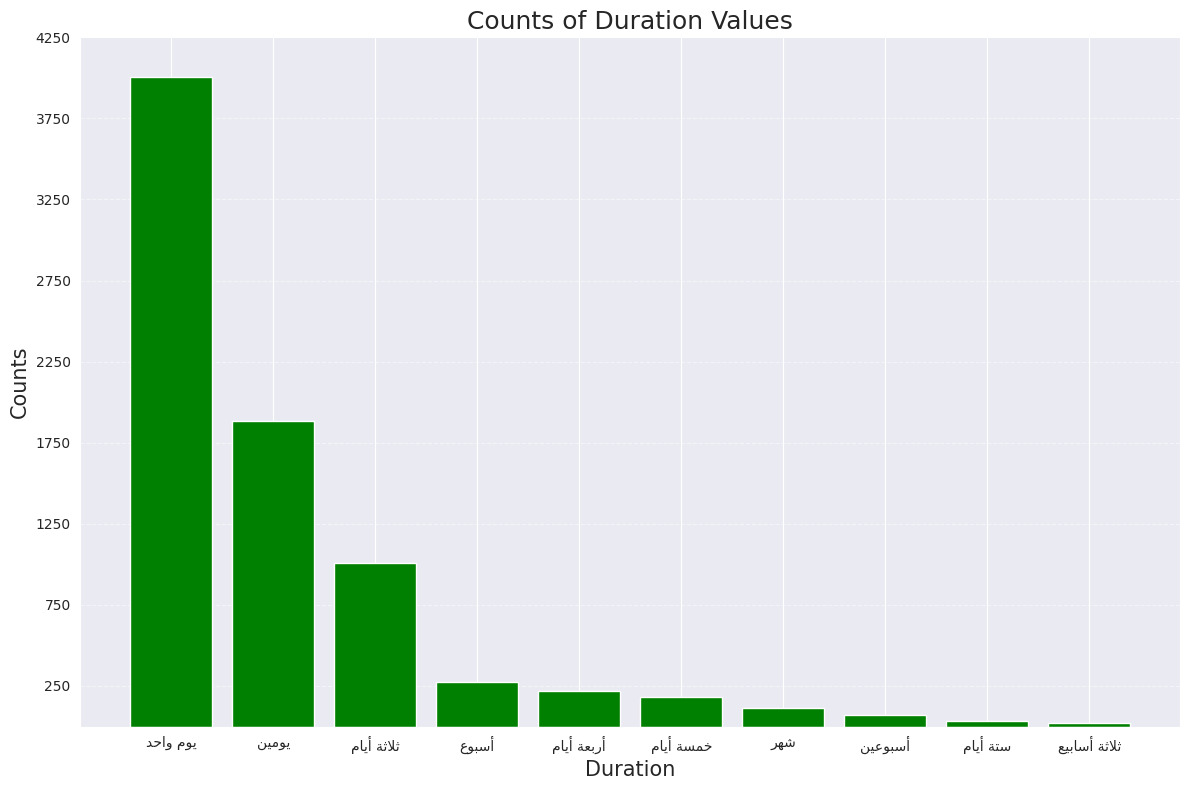

In [199]:
reshaped_labels = [arabic_reshaper.reshape(label) for label in duration_counts.index]
display_labels = [get_display(label) for label in reshaped_labels]

plt.figure(figsize=(12, 8))
plt.bar(display_labels, duration_counts.values, color="green")
plt.title("Counts of Duration Values", fontsize=18)
plt.xlabel("Duration", fontsize=15)
plt.ylabel("Counts", fontsize=15)
plt.xticks(fontsize=10)
plt.yticks(range(250, int(max(duration_counts.values)) + 500, 500), fontsize=10)
plt.grid(axis="y", alpha=0.5, linestyle="--")
plt.tight_layout()

plt.show()

#### Display the `Offer Response Time` values distribution:

In [200]:
offer_response_time_counts = dataset["Offer Response Time"].value_counts()

print(offer_response_time_counts)

Offer Response Time
لم يحسب    1806
ساعة        857
ساعتين      480
3 ساعات     347
يوم         315
           ... 
14 يوم        2
16 يوم        1
25 يوم        1
26 يوم        1
23 يوم        1
Name: count, Length: 104, dtype: int64


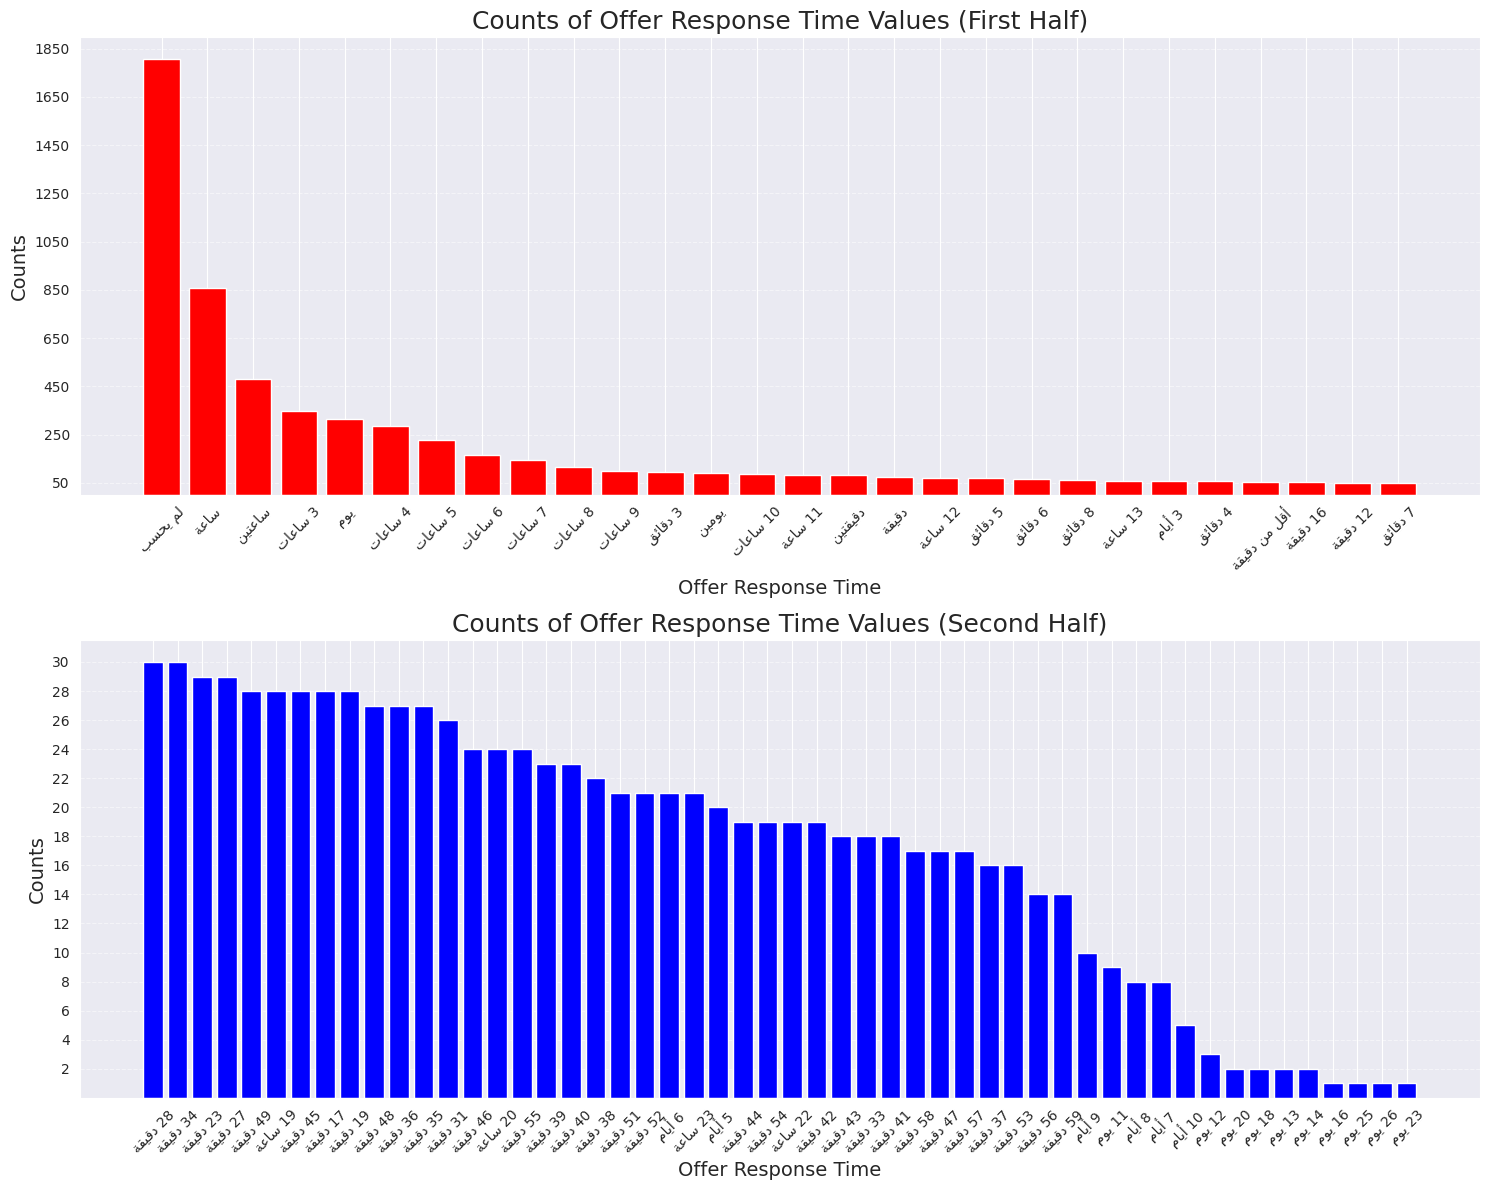

In [201]:
reshaped_labels = [arabic_reshaper.reshape(label) for label in offer_response_time_counts.index]
display_labels = [get_display(label) for label in reshaped_labels]

mid_index = len(display_labels) // 2

first_half_labels = display_labels[:mid_index]
first_half_values = offer_response_time_counts.values[:mid_index]

filtered_first_half_labels = []
filtered_first_half_values = []

for label, value in zip(first_half_labels, first_half_values):
    if value > 50:
        filtered_first_half_labels.append(label)
        filtered_first_half_values.append(value)

second_half_labels = display_labels[mid_index:]
second_half_values = offer_response_time_counts.values[mid_index:]

plt.figure(figsize=(15, 12))

plt.subplot(2, 1, 1)
plt.bar(filtered_first_half_labels, filtered_first_half_values, color="red")
plt.title("Counts of Offer Response Time Values (First Half)", fontsize=18)
plt.xlabel("Offer Response Time", fontsize=14)
plt.ylabel("Counts", fontsize=14)
plt.xticks(rotation=45, fontsize=10)
plt.yticks(range(50, int(max(filtered_first_half_values)) + 200, 200), fontsize=10)
plt.grid(axis="y", alpha=0.5, linestyle="--")
plt.tight_layout()

plt.subplot(2, 1, 2)
plt.bar(second_half_labels, second_half_values, color="blue")
plt.title("Counts of Offer Response Time Values (Second Half)", fontsize=18)
plt.xlabel("Offer Response Time", fontsize=14)
plt.ylabel("Counts", fontsize=14)
plt.xticks(rotation=45, fontsize=10)
plt.yticks(range(2, int(max(second_half_values)) + 2, 2), fontsize=10)
plt.grid(axis="y", alpha=0.5, linestyle="--")
plt.tight_layout()

plt.show()


#### Display the `Owner Response Time` values distribution:

In [202]:
owner_response_time_counts = dataset["Owner Response Time"].value_counts()

print(owner_response_time_counts)

Owner Response Time
لم يحسب    1258
ساعة        906
ساعتين      703
3 ساعات     547
4 ساعات     427
           ... 
12 يوم        2
10 أيام       1
22 يوم        1
13 يوم        1
17 يوم        1
Name: count, Length: 102, dtype: int64


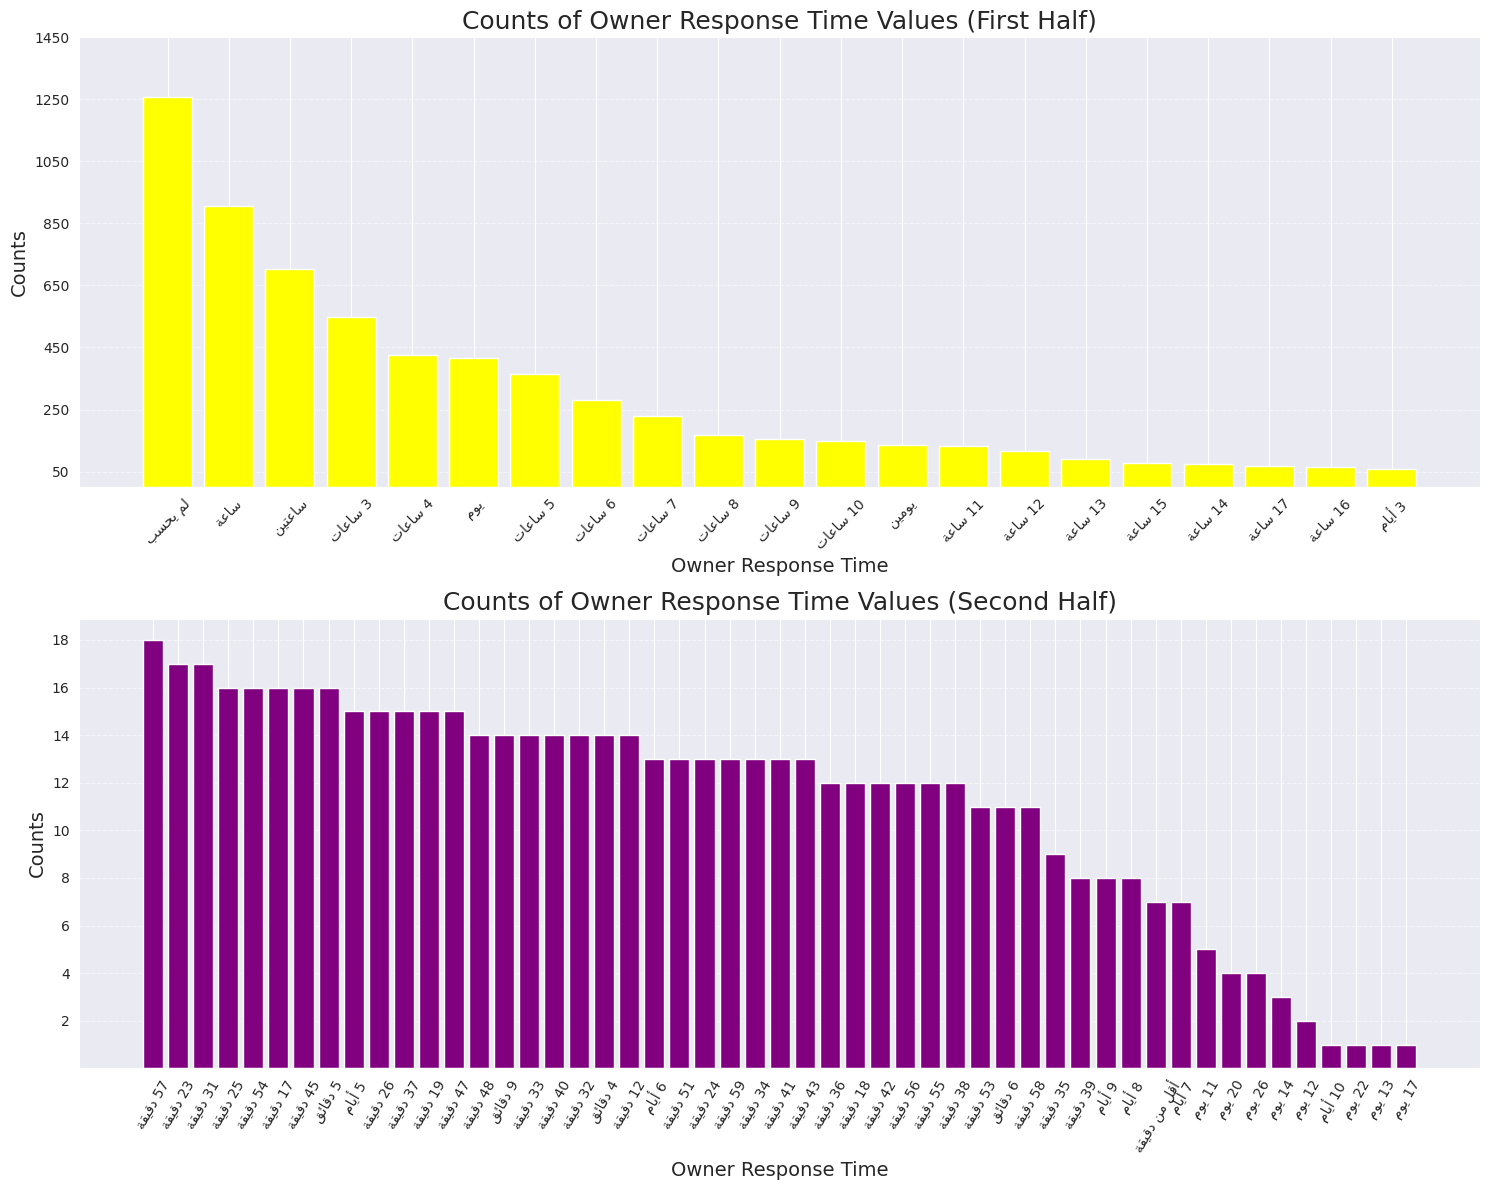

In [203]:
reshaped_labels = [arabic_reshaper.reshape(label) for label in owner_response_time_counts.index]
display_labels = [get_display(label) for label in reshaped_labels]

mid_index = len(display_labels) // 2

first_half_labels = display_labels[:mid_index]
first_half_values = owner_response_time_counts.values[:mid_index]

filtered_first_half_labels = []
filtered_first_half_values = []

for label, value in zip(first_half_labels, first_half_values):
    if value > 50:
        filtered_first_half_labels.append(label)
        filtered_first_half_values.append(value)

second_half_labels = display_labels[mid_index:]
second_half_values = owner_response_time_counts.values[mid_index:]

plt.figure(figsize=(15, 12))

plt.subplot(2, 1, 1)
plt.bar(filtered_first_half_labels, filtered_first_half_values, color="yellow")
plt.title("Counts of Owner Response Time Values (First Half)", fontsize=18)
plt.xlabel("Owner Response Time", fontsize=14)
plt.ylabel("Counts", fontsize=14)
plt.xticks(rotation=45, fontsize=10)
plt.yticks(range(50, int(max(filtered_first_half_values)) + 200, 200), fontsize=10)
plt.grid(axis="y", alpha=0.5, linestyle="--")
plt.tight_layout()

plt.subplot(2, 1, 2)
plt.bar(second_half_labels, second_half_values, color="purple")
plt.title("Counts of Owner Response Time Values (Second Half)", fontsize=18)
plt.xlabel("Owner Response Time", fontsize=14)
plt.ylabel("Counts", fontsize=14)
plt.xticks(rotation=60, fontsize=10)
plt.yticks(range(2, int(max(second_half_values)) + 2, 2), fontsize=10)
plt.grid(axis="y", alpha=0.5, linestyle="--")
plt.tight_layout()

plt.show()

#### Display the `Owner Completion Rate` values distribution:

In [204]:
owner_completion_rate_counts = dataset["Owner Completion Rate"].value_counts()

print(owner_completion_rate_counts)

Owner Completion Rate
100.0%         1484
لم يحسب بعد    1362
66.67%           73
85.71%           65
83.33%           65
               ... 
82.38%            1
84.3%             1
95.73%            1
66.0%             1
82.22%            1
Name: count, Length: 1240, dtype: int64


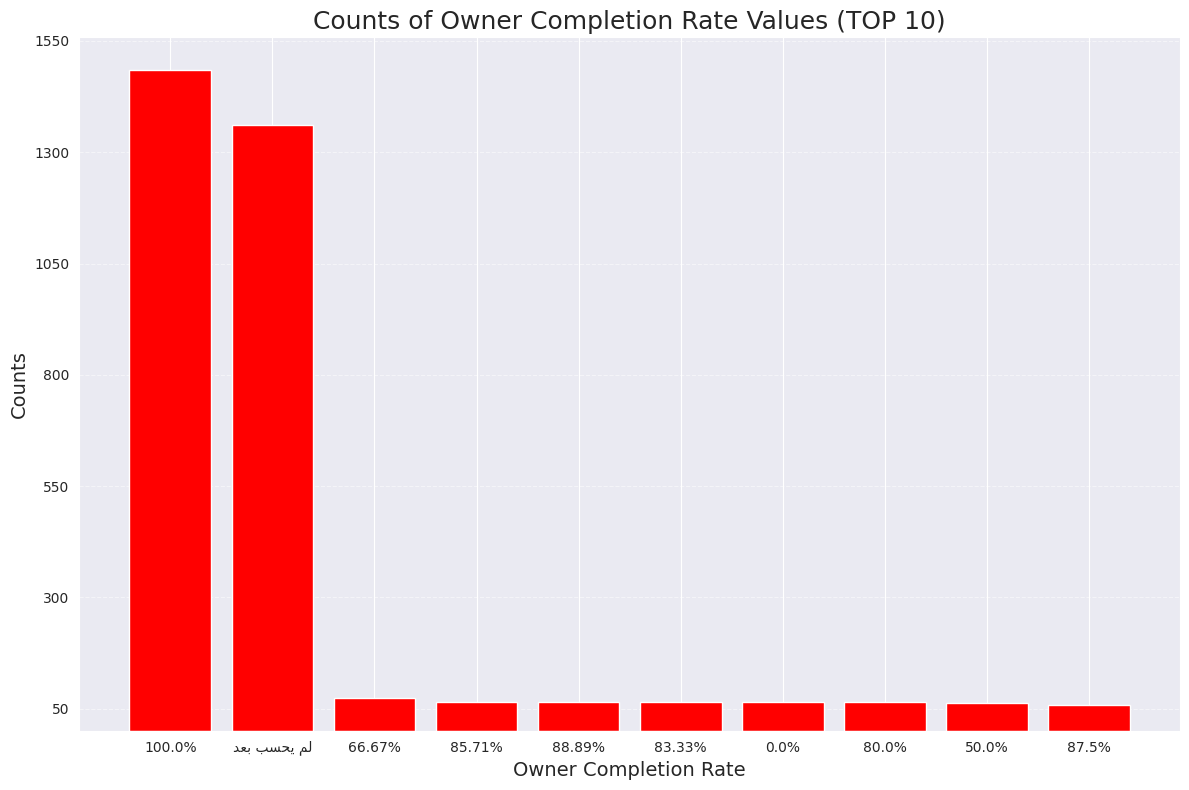

In [205]:
owner_completion_rate_counts_top = owner_completion_rate_counts.sort_values(ascending=False)[:10]

reshaped_labels = [arabic_reshaper.reshape(label) for label in owner_completion_rate_counts_top.index]
display_labels = [get_display(label) for label in reshaped_labels]

plt.figure(figsize=(12, 8))
plt.bar(display_labels, owner_completion_rate_counts_top.values, color="red")
plt.title("Counts of Owner Completion Rate Values (TOP 10)", fontsize=18)
plt.xlabel("Owner Completion Rate", fontsize=14)
plt.ylabel("Counts", fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(range(50, int(max(owner_completion_rate_counts_top.values)) + 250, 250), fontsize=10)
plt.grid(axis="y", alpha=0.5, linestyle="--")
plt.tight_layout()

plt.show()

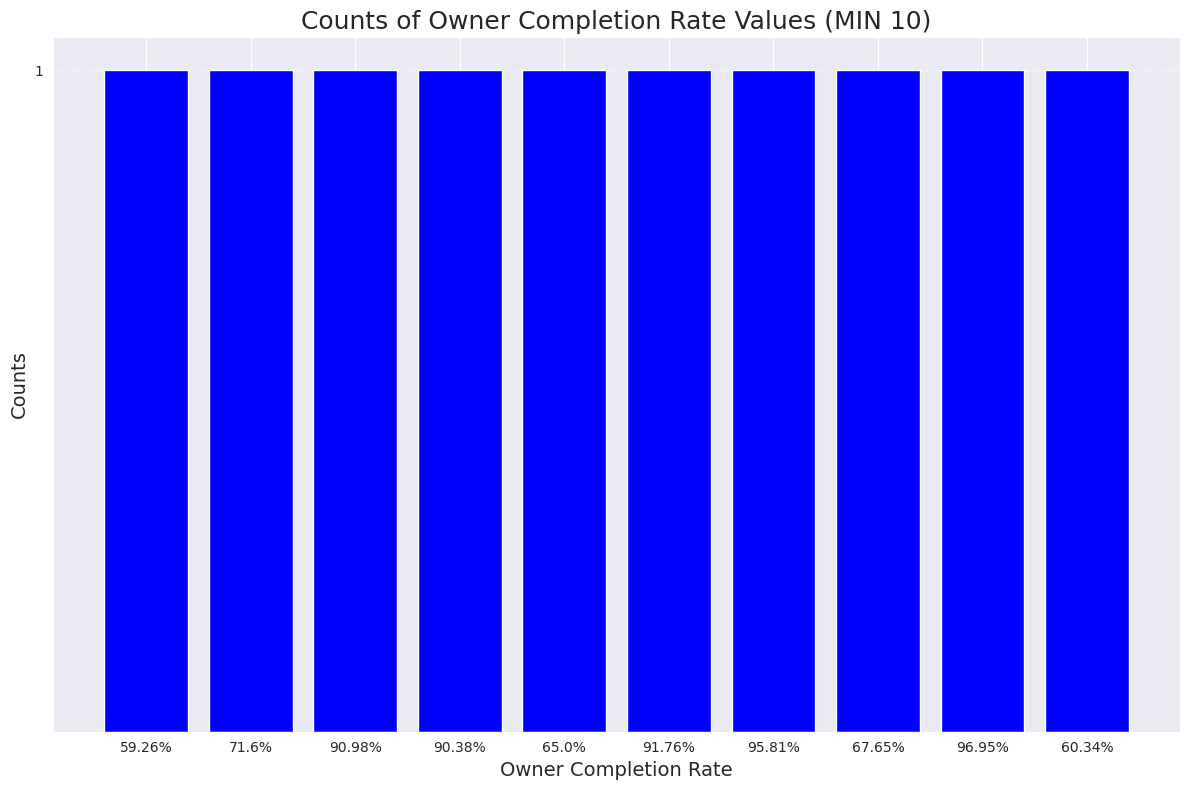

In [206]:
owner_completion_rate_counts_min = owner_completion_rate_counts.sort_values()[:10]

plt.figure(figsize=(12, 8))
plt.bar(owner_completion_rate_counts_min.index, owner_completion_rate_counts_min.values, color="blue")
plt.title("Counts of Owner Completion Rate Values (MIN 10)", fontsize=18)
plt.xlabel("Owner Completion Rate", fontsize=14)
plt.ylabel("Counts", fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(range(1, int(max(owner_completion_rate_counts_min.values)) + 1, 1), fontsize=10)
plt.grid(axis="y", alpha=0.5, linestyle="--")
plt.tight_layout()

plt.show()

#### Display the `Price` values distribution:

In [207]:
price_counts = dataset["Price"].value_counts()

print(price_counts)

Price
$5.00     4341
$10.00    2371
$25.00     379
$15.00     250
$20.00     210
$50.00     170
$30.00      50
$35.00      20
$40.00      17
$45.00      10
Name: count, dtype: int64


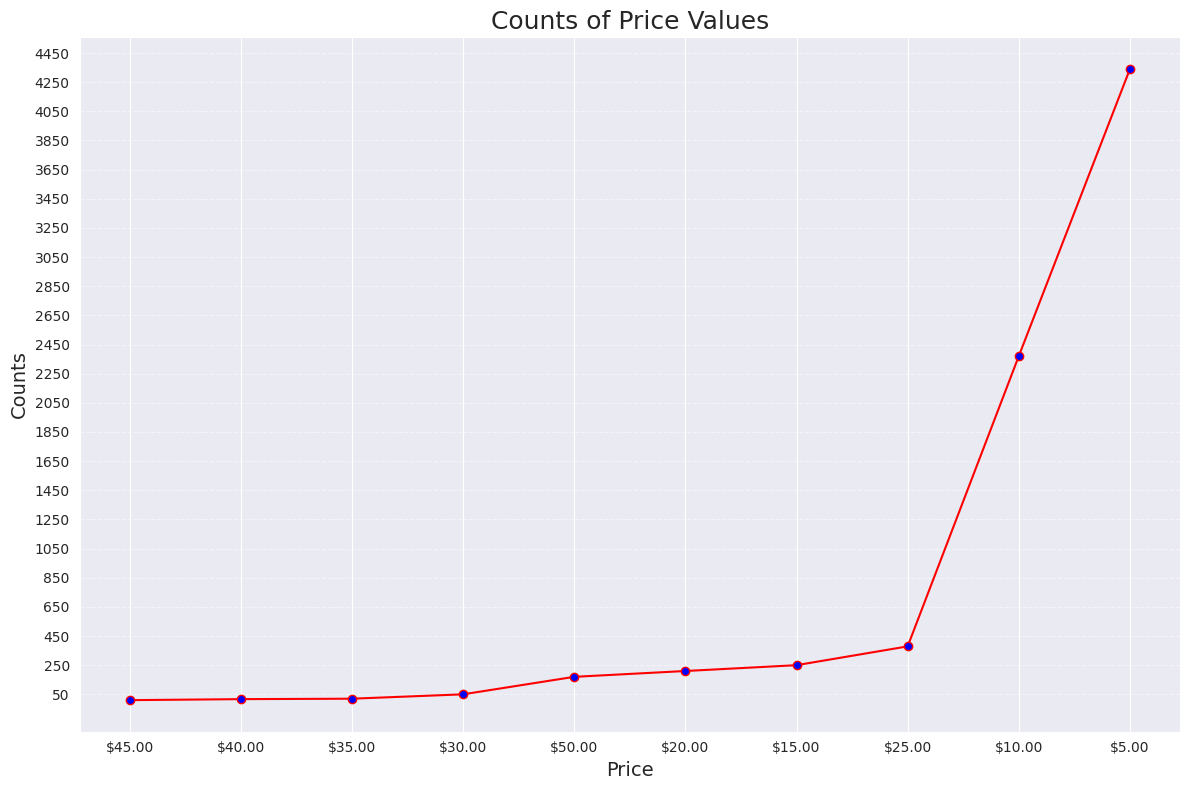

In [208]:
price_counts.sort_values(inplace=True)

plt.figure(figsize=(12, 8))
plt.plot(price_counts.index, price_counts.values, color="red", marker="o", markerfacecolor="blue")
plt.title("Counts of Price Values", fontsize=18)
plt.xlabel("Price", fontsize=14)
plt.ylabel("Counts", fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(range(50, 4500, 200), fontsize=10)
plt.grid(axis="y", alpha=0.5, linestyle="--")
plt.tight_layout()

plt.show()

#### Display the distribution of `Offer Stars` grouped by `Price`:    

In [209]:
offer_stars_counts = dataset["Offer Stars"].value_counts()

print(offer_stars_counts)

Offer Stars
5.0    4347
0.0    2133
4.5    1231
3.5      42
4.0      35
3.0      18
1.0       8
2.5       2
2.0       1
1.5       1
Name: count, dtype: int64


In [210]:
offer_stars_grouped_with_price = dataset.groupby(["Offer Stars", "Price"]).size().reset_index(name="Count")

offer_stars_grouped_with_price

,Offer Stars,Price,Count
0,0.0,$10.00,743
1,0.0,$15.00,23
2,0.0,$20.00,12
3,0.0,$25.00,27
4,0.0,$30.00,2
5,0.0,$35.00,2
6,0.0,$45.00,3
7,0.0,$5.00,1300
8,0.0,$50.00,21
9,1.0,$10.00,4


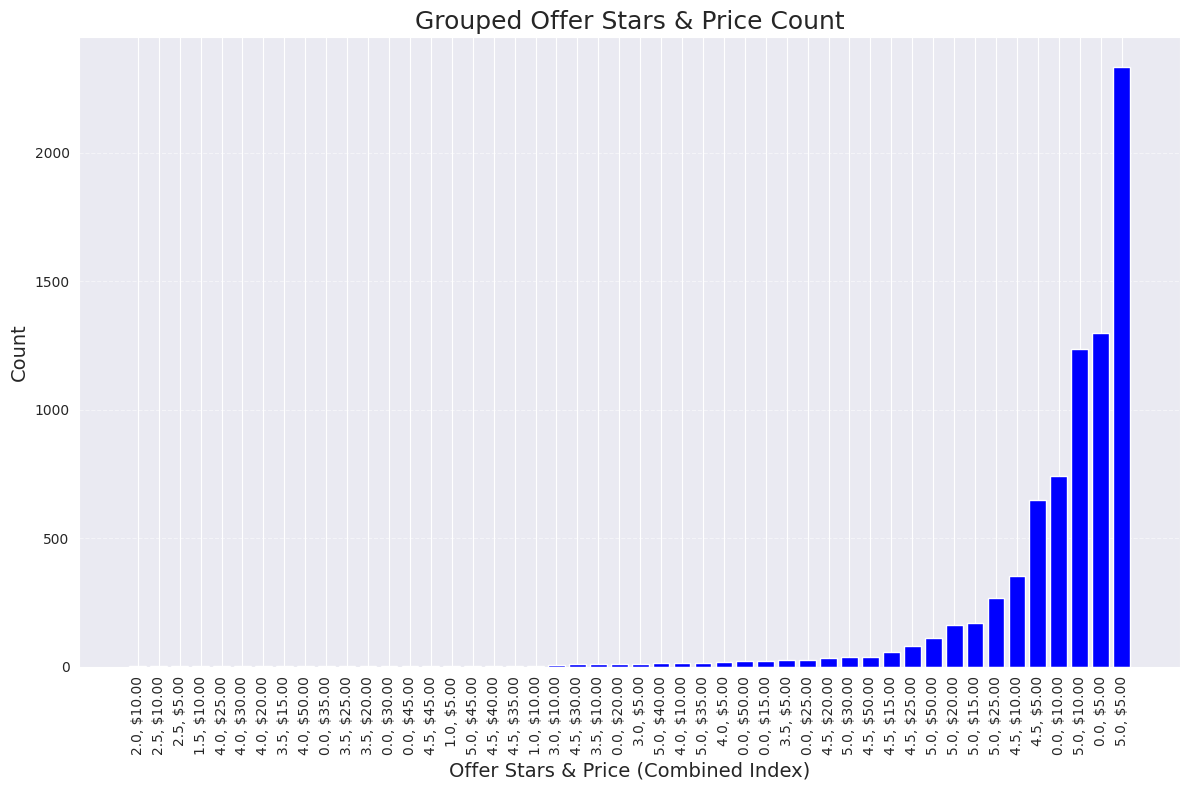

In [211]:
offer_stars_grouped_with_price = offer_stars_grouped_with_price.sort_values(by="Count").reset_index(drop=True)

plt.figure(figsize=(12, 8))
plt.bar(x=range(len(offer_stars_grouped_with_price)), height=offer_stars_grouped_with_price["Count"], color="blue",
        width=0.8)
plt.title("Grouped Offer Stars & Price Count", fontsize=18)
plt.xlabel("Offer Stars & Price (Combined Index)", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.xticks(ticks=range(len(offer_stars_grouped_with_price)),
           labels=[f"{row['Offer Stars']}, {row['Price']}" for _, row in offer_stars_grouped_with_price.iterrows()],
           rotation=90, fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis="y", alpha=0.5, linestyle="--")

plt.tight_layout()
plt.show()

#### Display the distribution of `Owner Stars` grouped by `Price`:    

In [212]:
owner_stars_counts = dataset["Owner Stars"].value_counts()

print(owner_stars_counts)

Owner Stars
5.0    4307
4.5    1766
0.0    1629
3.5      54
4.0      34
3.0      17
1.0       6
2.5       4
2.0       1
Name: count, dtype: int64


In [213]:
owner_stars_grouped_with_price = dataset.groupby(["Owner Stars", "Price"]).size().reset_index(name="Count")

owner_stars_grouped_with_price

,Owner Stars,Price,Count
0,0.0,$10.00,601
1,0.0,$15.00,3
2,0.0,$20.00,2
3,0.0,$25.00,3
4,0.0,$5.00,1019
5,0.0,$50.00,1
6,1.0,$5.00,6
7,2.0,$10.00,1
8,2.5,$5.00,4
9,3.0,$10.00,6


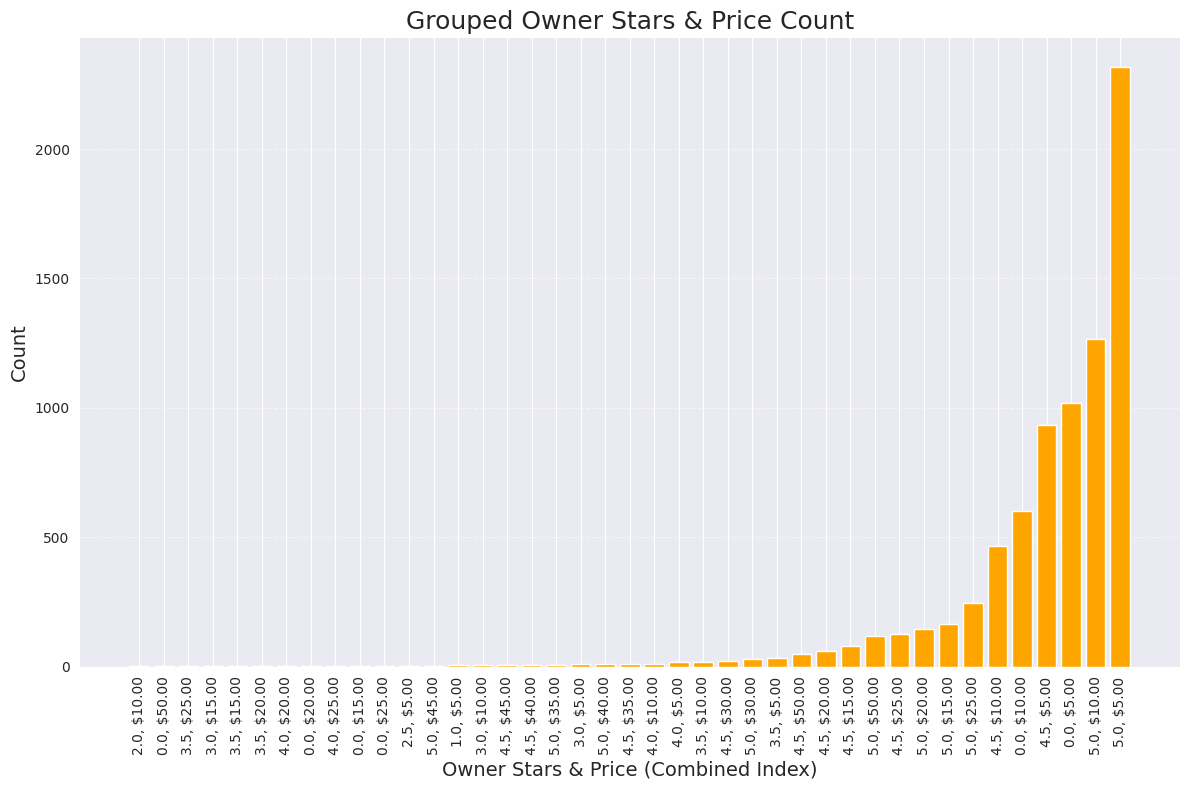

In [214]:
owner_stars_grouped_with_price = owner_stars_grouped_with_price.sort_values(by="Count").reset_index(drop=True)

plt.figure(figsize=(12, 8))
plt.bar(x=range(len(owner_stars_grouped_with_price)), height=owner_stars_grouped_with_price["Count"], color="orange",
        width=0.8)
plt.title("Grouped Owner Stars & Price Count", fontsize=18)
plt.xlabel("Owner Stars & Price (Combined Index)", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.xticks(ticks=range(len(owner_stars_grouped_with_price)),
           labels=[f"{row['Owner Stars']}, {row['Price']}" for _, row in owner_stars_grouped_with_price.iterrows()],
           rotation=90, fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis="y", alpha=0.5, linestyle="--")

plt.tight_layout()
plt.show()

#### Display the `Owner Level` values distribution:

In [215]:
owner_level_counts = dataset["Owner Level"].value_counts()

print(owner_level_counts)

Owner Level
بائع مميز      2851
بائع جديد      2620
بائع نشيط      1984
بائع موثوق      116
مشتري مميز       80
مشتري جديد       71
مشتري VIP        45
مشتري جاد        45
مستخدم جديد       6
Name: count, dtype: int64


#### Display the distribution of `Price` across different `Owner Levels`:

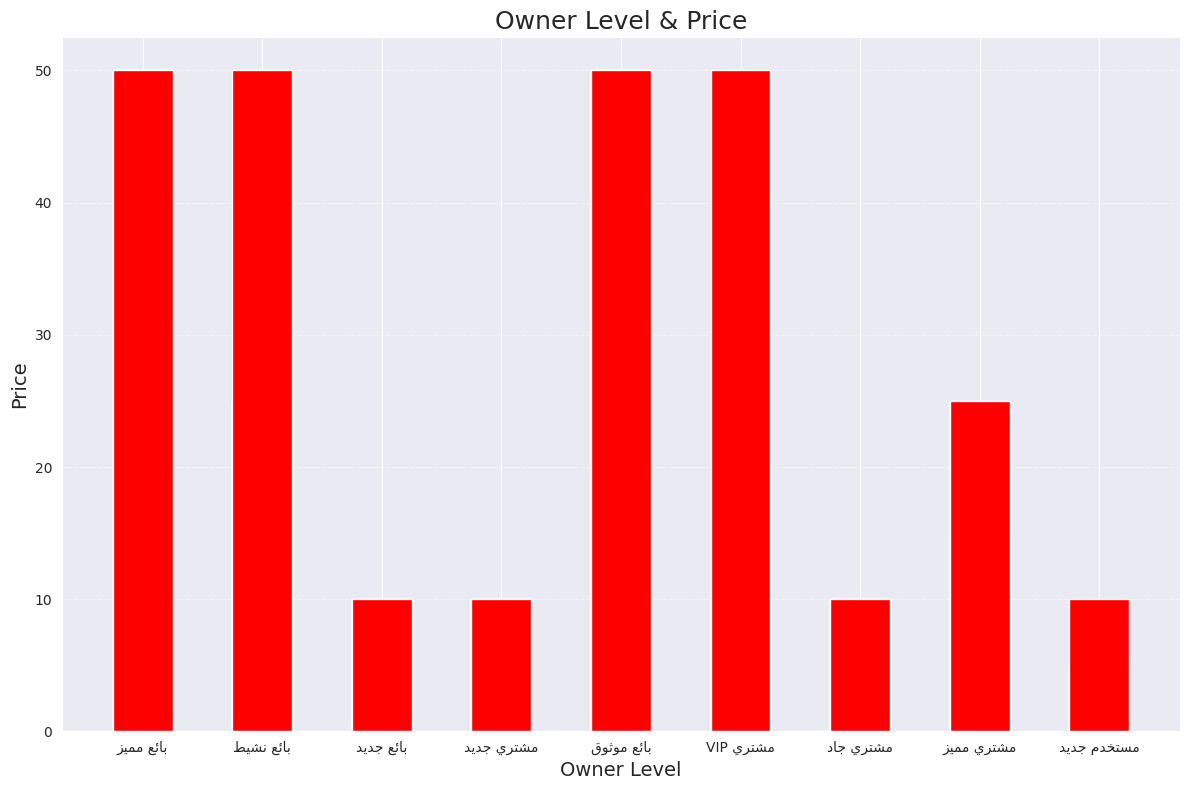

In [216]:
dataset["Price"] = dataset["Price"].replace("[\$,]", "", regex=True).astype(float)

sorted_dataset = dataset.sort_values(by="Price")

reshaped_labels = [arabic_reshaper.reshape(label) for label in sorted_dataset["Owner Level"]]
display_labels = [get_display(label) for label in reshaped_labels]

plt.figure(figsize=(12, 8))
plt.bar(display_labels, sorted_dataset["Price"], color="red", width=0.5)
plt.title("Owner Level & Price", fontsize=18)
plt.xlabel("Owner Level", fontsize=14)
plt.ylabel("Price", fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis="y", alpha=0.5, linestyle="--")
plt.tight_layout()

plt.show()

#### Convert `Owner Completion Rate`, `Duration`, `Offer Response Time`, and `Owner Response Time` to numeric values for easier analysis:

In [217]:
dataset["Owner Completion Rate"] = dataset["Owner Completion Rate"].mask(dataset["Owner Completion Rate"] == "لم يحسب بعد")
dataset["Owner Completion Rate"] = dataset["Owner Completion Rate"].replace("[\%,]", "", regex=True).astype(float)
dataset = to_numeric(dataset, columns=["Duration", "Offer Response Time", "Owner Response Time"])

In [218]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7818 entries, 0 to 7817
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Category Name          7818 non-null   object 
 1   Category URL           7818 non-null   object 
 2   Service Name           7818 non-null   object 
 3   Service URL            7818 non-null   object 
 4   Offer Name             7818 non-null   object 
 5   Offer URL              7818 non-null   object 
 6   Offer Stars            7818 non-null   float64
 7   Offer Raters           7818 non-null   int64  
 8   Offer Response Time    6012 non-null   float64
 9   Offer Buyers           7818 non-null   int64  
 10  Pending                7818 non-null   int64  
 11  Price                  7818 non-null   float64
 12  Duration               7818 non-null   int64  
 13  Reviews                7818 non-null   int64  
 14  Available Additions    7818 non-null   int64  
 15  Addi

#### Display features with missing values after conversion, and their counts:

In [219]:
dataset.columns[dataset.isna().any()].values

array(['Offer Response Time', 'Owner Completion Rate',
       'Owner Response Time'], dtype=object)

In [220]:
dataset.isna().sum()[dataset.isna().any()]

Offer Response Time      1806
Owner Completion Rate    1362
Owner Response Time      1258
dtype: int64

#### Calculate the linear correlations (Pearson's r) between numerical features:

In [221]:
correlation = dataset.select_dtypes(include=["float64", "int64", "bool"]).corr()

correlation

,Offer Stars,Offer Raters,Offer Response Time,Offer Buyers,Pending,Price,Duration,Reviews,Available Additions,Additions Price,Owner Verified,Owner Stars,Owner Raters,Owner Completion Rate,Owner Services,Owner Customers,Owner Response Time
Offer Stars,1.000000,0.244270,-0.064358,0.225626,0.105692,0.132717,0.066086,0.464556,0.317984,0.249490,0.429240,0.832514,0.250201,0.233541,0.202737,0.235031,-0.130526
Offer Raters,0.244270,1.000000,-0.029990,0.980466,0.175266,0.093609,0.043450,0.684926,0.248509,0.204829,0.120803,0.205450,0.558053,0.092088,0.064880,0.568685,-0.039136
Offer Response Time,-0.064358,-0.029990,1.000000,-0.024893,-0.005208,-0.037823,0.014051,-0.039439,-0.019280,0.013723,-0.034834,-0.052951,-0.034023,-0.056830,-0.043224,-0.027962,0.588418
Offer Buyers,0.225626,0.980466,-0.024893,1.000000,0.179318,0.082699,0.057496,0.652421,0.221552,0.182733,0.113549,0.189785,0.556014,0.088164,0.065530,0.589110,-0.033322
Pending,0.105692,0.175266,-0.005208,0.179318,1.000000,0.051882,0.051944,0.188209,0.117811,0.114715,0.058940,0.093354,0.079442,0.021958,0.009353,0.088987,-0.012667
Price,0.132717,0.093609,-0.037823,0.082699,0.051882,1.000000,0.131626,0.139550,0.057321,0.308082,0.097847,0.157958,0.195740,0.016703,0.243265,0.174025,-0.042829
Duration,0.066086,0.043450,0.014051,0.057496,0.051944,0.131626,1.000000,0.052632,0.005468,0.077364,0.026193,0.063036,0.104345,-0.027313,0.038201,0.112594,0.011002
Reviews,0.464556,0.684926,-0.039439,0.652421,0.188209,0.139550,0.052632,1.000000,0.370275,0.302476,0.222808,0.390045,0.470112,0.125882,0.129754,0.461772,-0.067430
Available Additions,0.317984,0.248509,-0.019280,0.221552,0.117811,0.057321,0.005468,0.370275,1.000000,0.610348,0.186675,0.274399,0.160010,0.073254,0.067862,0.143882,-0.041387
Additions Price,0.249490,0.204829,0.013723,0.182733,0.114715,0.308082,0.077364,0.302476,0.610348,1.000000,0.138419,0.223698,0.166539,0.014937,0.109593,0.149928,-0.026974


#### Sort the correlation values of `Price` with other features:

In [222]:
correlation["Price"].sort_values(ascending=False)

Price                    1.000000
Additions Price          0.308082
Owner Services           0.243265
Owner Raters             0.195740
Owner Customers          0.174025
Owner Stars              0.157958
Reviews                  0.139550
Offer Stars              0.132717
Duration                 0.131626
Owner Verified           0.097847
Offer Raters             0.093609
Offer Buyers             0.082699
Available Additions      0.057321
Pending                  0.051882
Owner Completion Rate    0.016703
Offer Response Time     -0.037823
Owner Response Time     -0.042829
Name: Price, dtype: float64

#### Display the correlation heatmap (Pearson's r):

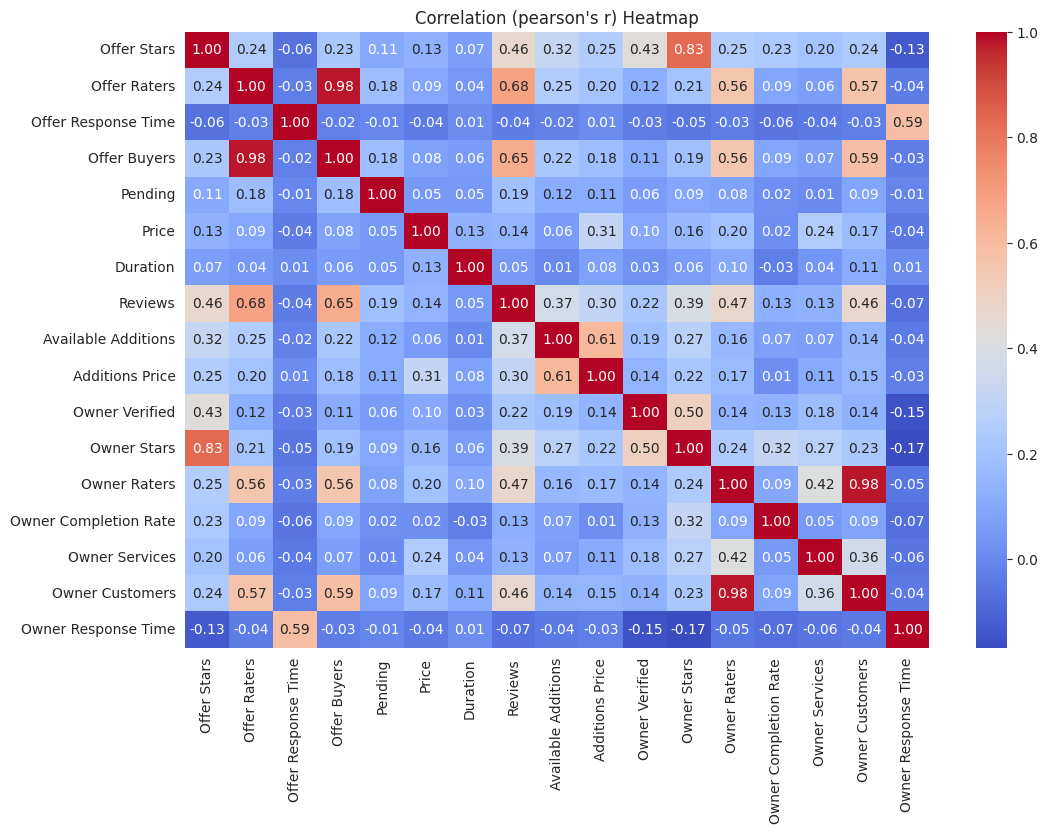

In [223]:
plt.figure(figsize=(12, 8))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation (pearson's r) Heatmap")
plt.show()

#### Calculate and display correlation between features and `Price`, including for categorical features:

In [224]:
def correlation_ratio(categories, values) -> np.ndarray:
    """
    TODO
    :param categories: 
    :param values: 
    :return: 
    """
    categories = pd.Categorical(categories)
    mean_total = values.mean()
    numerator = sum([len(values[categories == category]) * (values[categories == category].mean() - mean_total) ** 2 for category in categories.categories])
    denominator = sum((values - mean_total) ** 2)

    return np.sqrt(numerator / denominator)


categorical_columns = dataset.select_dtypes(include=["object"]).columns
numerical_columns = dataset.select_dtypes(include=["int64", "float64", "bool"]).columns

numerical_price_column = dataset["Price"]

overall_correlations = {}

for num_col in numerical_columns:
    correlation = dataset[num_col].corr(numerical_price_column)
    overall_correlations[num_col] = correlation

for cat_col in categorical_columns:
    ratio = correlation_ratio(dataset[cat_col], numerical_price_column)
    overall_correlations[cat_col] = ratio

overall_percentage = {k: v * 100 if isinstance(v, (int, float)) else v * 100 for k, v in overall_correlations.items()}

overall_correlation_df = pd.DataFrame(list(overall_percentage.items()), columns=["Feature", "Correlation"]).sort_values(by="Correlation", ascending=False).reset_index(drop=True)

features_to_drop = ["Offer Name", "Offer URL", "Owner Name", "Owner URL", "Service URL", "Category URL"]

overall_correlation_df = overall_correlation_df[~overall_correlation_df["Feature"].isin(features_to_drop)]

overall_correlation_df

,Feature,Correlation
0,Price,100.000000
6,Service Name,44.164211
7,Additions Price,30.808227
8,Owner Level,29.330027
9,Owner Services,24.326459
10,Owner Raters,19.573953
11,Owner Customers,17.402519
12,Owner Stars,15.795840
13,Category Name,14.549751
15,Reviews,13.955004


#### Display the correlation percentages of features with `Price`:

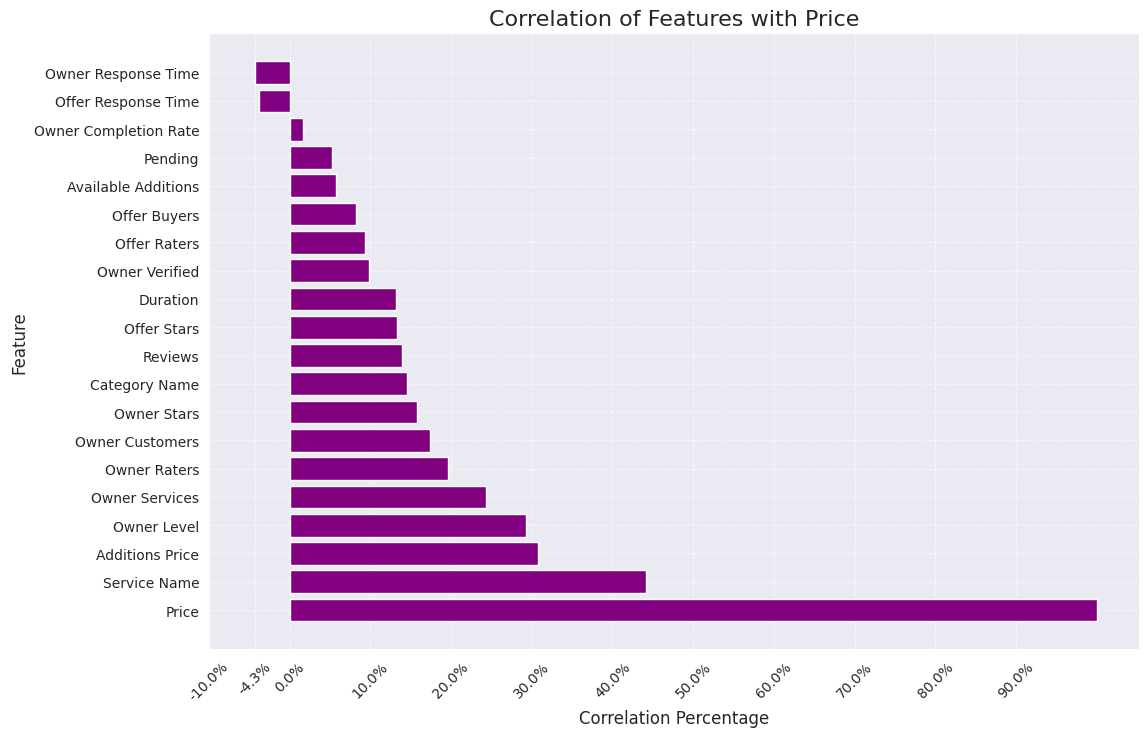

In [225]:
plt.figure(figsize=(12, 8))

plt.barh(overall_correlation_df["Feature"], overall_correlation_df["Correlation"], color="purple")

plt.title("Correlation of Features with Price", fontsize=16)
plt.xlabel("Correlation Percentage", fontsize=12)
plt.ylabel("Feature", fontsize=12)

min_corr = overall_correlation_df["Correlation"].min()
max_corr = overall_correlation_df["Correlation"].max()

x_ticks = range(int(min_corr // 10) * 10, int(max_corr // 10) * 10 + 10, 10)

if min_corr not in x_ticks:
    x_ticks = [min_corr] + list(x_ticks)

plt.xticks(ticks=x_ticks, labels=[f"{x:.1f}%" for x in x_ticks], rotation=45)
plt.grid(alpha=0.6, linestyle="--")

plt.show()

#### Display `Price` across different `Owner Level & Price` combinations:

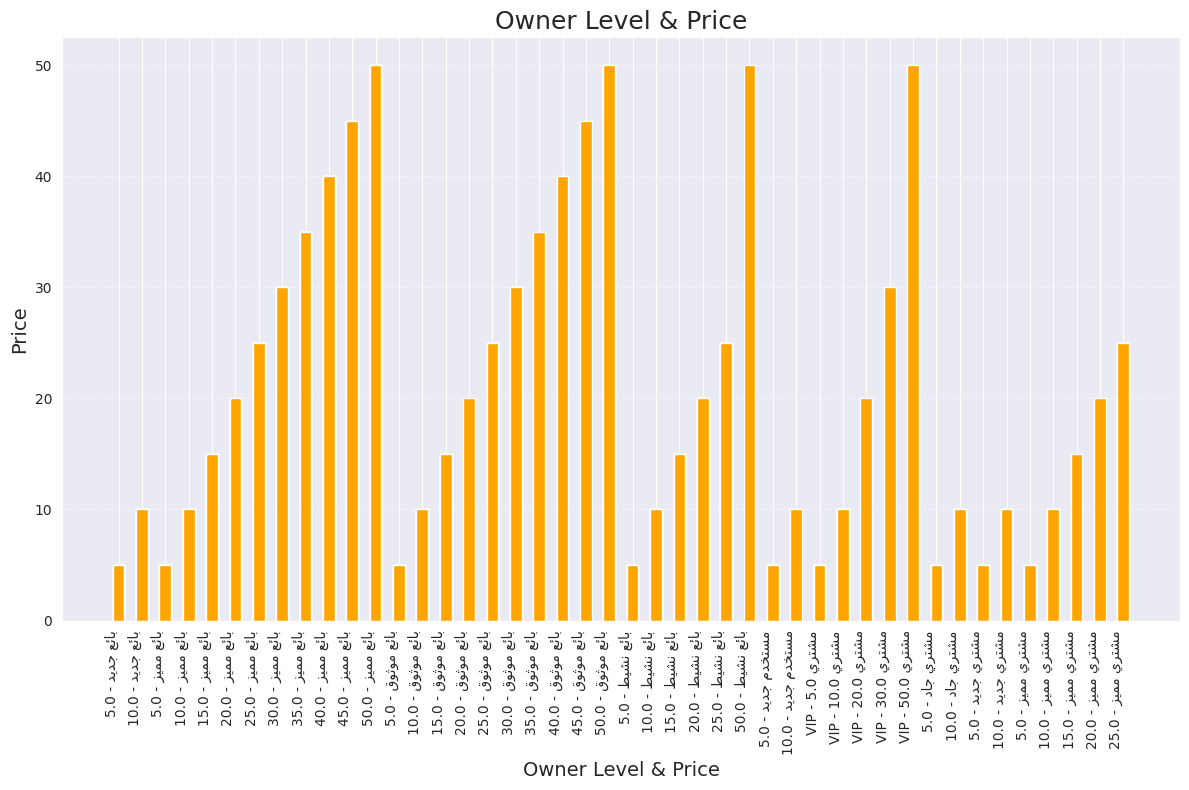

In [226]:
dataset["Owner Level & Price"] = dataset["Owner Level"].astype(str) + " - " + dataset["Price"].astype(
    str)

sorted_dataset = dataset.sort_values(by=["Owner Level", "Price"])

reshaped_labels = [arabic_reshaper.reshape(label) for label in sorted_dataset["Owner Level & Price"]]
display_labels = [get_display(label) for label in reshaped_labels]

plt.figure(figsize=(12, 8))
plt.bar(display_labels, sorted_dataset["Price"], color="orange", width=0.5)
plt.title("Owner Level & Price", fontsize=18)
plt.xlabel("Owner Level & Price", fontsize=14)
plt.ylabel("Price", fontsize=14)
plt.xticks(fontsize=10, rotation=90, ha="right")
plt.yticks(fontsize=10)
plt.grid(axis="y", alpha=0.5, linestyle="--")
plt.tight_layout()

plt.show()

dataset.drop(columns=["Owner Level & Price"], inplace=True)

In [227]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7818 entries, 0 to 7817
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Category Name          7818 non-null   object 
 1   Category URL           7818 non-null   object 
 2   Service Name           7818 non-null   object 
 3   Service URL            7818 non-null   object 
 4   Offer Name             7818 non-null   object 
 5   Offer URL              7818 non-null   object 
 6   Offer Stars            7818 non-null   float64
 7   Offer Raters           7818 non-null   int64  
 8   Offer Response Time    6012 non-null   float64
 9   Offer Buyers           7818 non-null   int64  
 10  Pending                7818 non-null   int64  
 11  Price                  7818 non-null   float64
 12  Duration               7818 non-null   int64  
 13  Reviews                7818 non-null   int64  
 14  Available Additions    7818 non-null   int64  
 15  Addi

#### Display the top `Price` for each `Owner Level`:

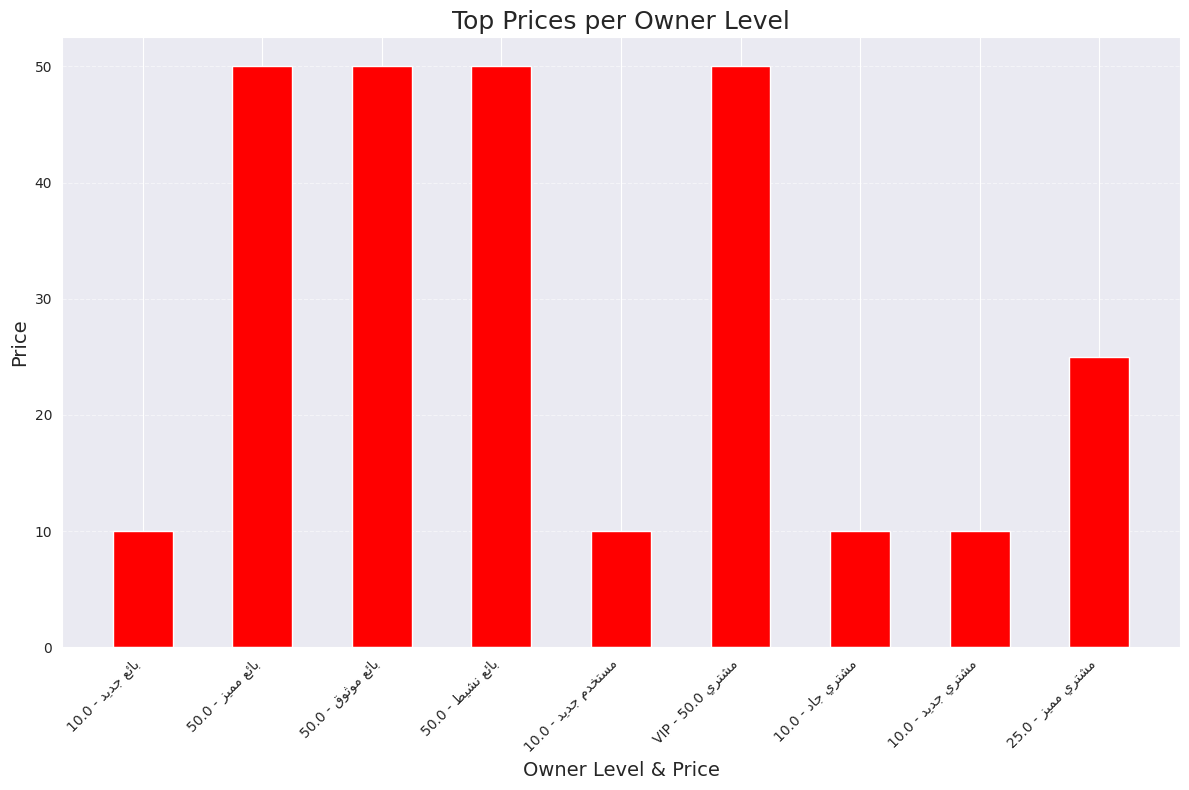

In [228]:
top_prices_per_owner = dataset.groupby("Owner Level", group_keys=False).apply(lambda x: x.nlargest(1, "Price"))

top_prices_per_owner["Owner Level & Price"] = (top_prices_per_owner["Owner Level"].astype(str) + " - " + top_prices_per_owner["Price"].astype(str))

reshaped_labels = [arabic_reshaper.reshape(label) for label in top_prices_per_owner["Owner Level & Price"]]
display_labels = [get_display(label) for label in reshaped_labels]

plt.figure(figsize=(12, 8))
plt.bar(display_labels, top_prices_per_owner["Price"], color="red", width=0.5)
plt.title("Top Prices per Owner Level", fontsize=18)
plt.xlabel("Owner Level & Price", fontsize=14)
plt.ylabel("Price", fontsize=14)
plt.xticks(fontsize=10, rotation=45, ha="right")
plt.yticks(fontsize=10)
plt.grid(axis="y", alpha=0.5, linestyle="--")
plt.tight_layout()

plt.show()

#### Analyze the distribution of some features for entries with `Price` equal to 50:

In [229]:
price_50_entries = dataset[dataset["Price"] == 50]

price_50_entries.shape[0]

170

#### For `Owner Level`:

In [230]:
price_50_entries.groupby("Owner Level").size().reset_index(name="count").sort_values(by="count", ascending=False)

,Owner Level,count
0,بائع مميز,148
1,بائع موثوق,19
3,مشتري VIP,2
2,بائع نشيط,1


#### For `Owner Stars`:

In [231]:
price_50_entries.groupby("Owner Stars").size().reset_index(name="count").sort_values(by="count", ascending=False)

,Owner Stars,count
2,5.0,118
1,4.5,51
0,0.0,1


#### For `Offer Stars`:

In [232]:
price_50_entries.groupby("Offer Stars").size().reset_index(name="count").sort_values(by="count", ascending=False)


,Offer Stars,count
3,5.0,112
2,4.5,36
0,0.0,21
1,4.0,1


#### For `Owner Verified`:

In [233]:
price_50_entries.groupby("Owner Verified").size().reset_index(name="count").sort_values(by="count", ascending=False)

,Owner Verified,count
0,True,170


#### Counting and Grouping `Unverified Owners` by `Price`:

In [234]:
owner_verified_false = dataset[dataset["Owner Verified"] == False]

owner_verified_false.shape[0]

629

In [235]:
owner_verified_false.groupby("Price").size().reset_index(name="count").sort_values(by="count", ascending=False)

,Price,count
0,5.0,416
1,10.0,210
2,15.0,1
3,25.0,1
4,40.0,1


#### For `Category Name`:

In [236]:
price_50_entries.groupby("Category Name").size().reset_index(name="count").sort_values(by="count", ascending=False)

,Category Name,count
1,برمجة وتطوير,49
4,تصميم,29
0,أعمال,27
3,تسويق رقمي,24
8,كتابة وترجمة,12
7,فيديو وأنيميشن,12
9,هندسة وعمارة,8
5,تعليم عن بعد,5
6,صوتيات,3
2,بيانات,1


#### Top 10 `Service Name` and `Category Name` combinations for entries with `Price` equal to 50

In [237]:
price_50_entries.groupby(["Service Name", "Category Name"]).size().reset_index(name="count").sort_values(by="count", ascending=False)[:10]

,Service Name,Category Name,count
3,أوبن كارت,برمجة وتطوير,9
65,دراسة جدوى,أعمال,8
49,تصميم هوية بصرية,تصميم,8
51,تطبيقات سطح المكتب,برمجة وتطوير,8
44,تصميم شعار,تصميم,7
63,خطط العمل,أعمال,6
64,خطط تسويقية,تسويق رقمي,6
7,إعداد وكتابة البحوث,كتابة وترجمة,4
12,إنشاء موقع إلكتروني,برمجة وتطوير,4
36,تصاميم معمارية تجارية,هندسة وعمارة,3


#### Calculate the mean, median, standard deviation of `Offer Response Time`, and `Owner Response Time`, `Owner Completion Rate`:

In [238]:
columns = ["Offer Response Time", "Owner Response Time", "Owner Completion Rate"]

statistical_data = ["mean", "median", "std"]

dataset[columns].agg(statistical_data).round(2).T

,mean,median,std
Offer Response Time,9.70,2.00,31.44
Owner Response Time,10.61,4.00,30.33
Owner Completion Rate,89.48,93.75,14.55


#### Display the `Offer Response Time`, `Owner Response Time`, and `Owner Completion Rate` distribution before filling:

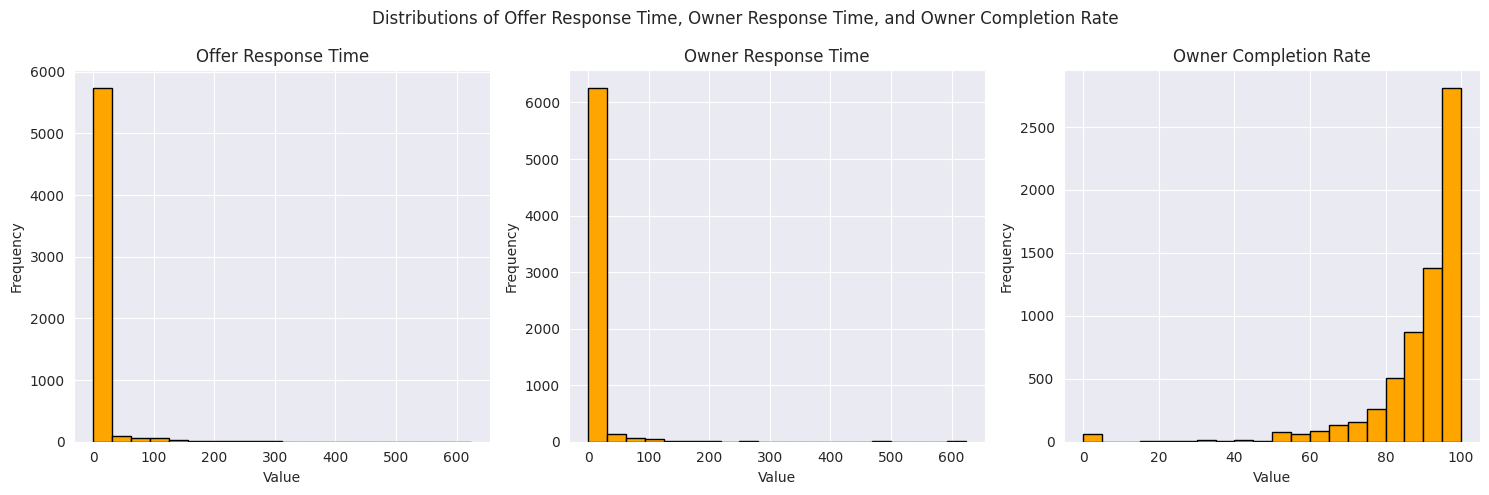

In [239]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Distributions of Offer Response Time, Owner Response Time, and Owner Completion Rate")

for i, col in enumerate(columns):
    axes[i].hist(dataset[col], bins=20, color="orange", edgecolor="black")
    axes[i].set_title(col)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

#### Display the `Offer Response Time`, `Owner Response Time`, and `Owner Completion Rate` distribution before filling:

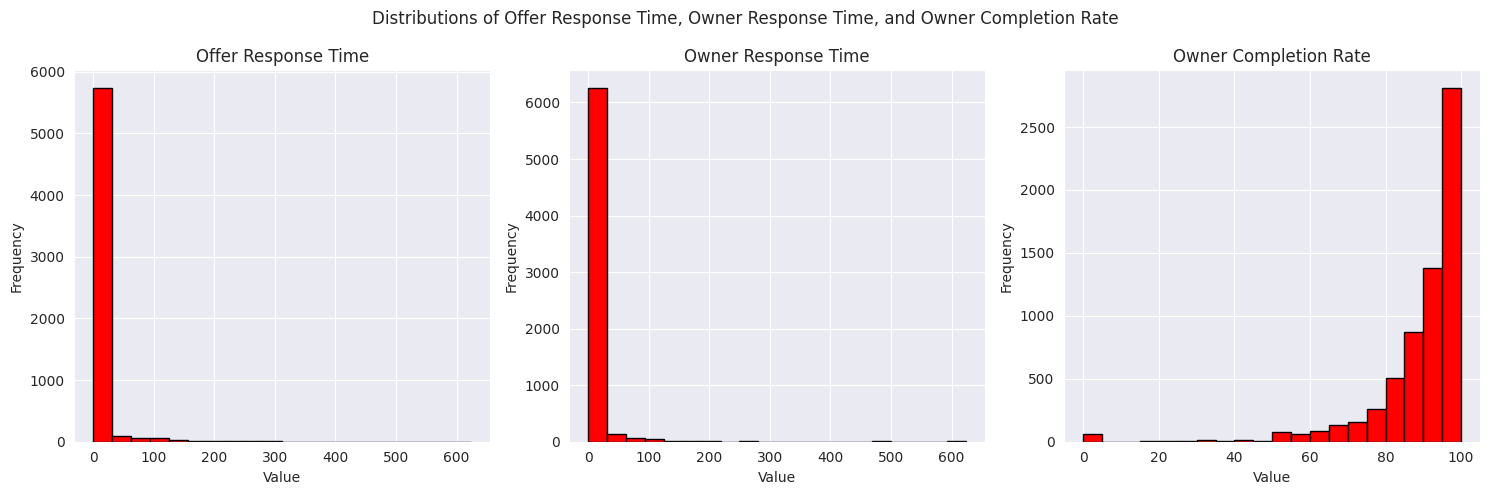

In [240]:
import matplotlib.pyplot as plt

with_median = dataset.fillna(statistical_data[1])

for col in columns:
    with_median[col] = pd.to_numeric(with_median[col], errors="coerce")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Distributions of Offer Response Time, Owner Response Time, and Owner Completion Rate")

for i, col in enumerate(columns):
    numeric_data = with_median[col]
    axes[i].hist(numeric_data, bins=20, color="red", edgecolor="black")
    axes[i].set_title(col)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

#### Identifying top `Price` listings per `Owner Level` with frequency count to determine the order of encoded labels:

In [241]:
top_prices_per_owner = (dataset.groupby("Owner Level", group_keys=False).apply(lambda x: x.nlargest(1, "Price")))

top_prices_per_owner["Frequency"] = top_prices_per_owner.apply(lambda row: dataset[(dataset["Owner Level"] == row["Owner Level"]) & (dataset["Price"] == row["Price"])].shape[0], axis=1)

top_prices_per_owner[["Owner Level", "Price", "Frequency"]].sort_values(by=["Price", "Frequency"], ascending=False).reset_index(drop=True)

,Owner Level,Price,Frequency
0,بائع مميز,50.0,148
1,بائع موثوق,50.0,19
2,مشتري VIP,50.0,2
3,بائع نشيط,50.0,1
4,مشتري مميز,25.0,4
5,بائع جديد,10.0,1021
6,مشتري جديد,10.0,29
7,مشتري جاد,10.0,22
8,مستخدم جديد,10.0,1


#### Ordering `Owner Level` based on top `Price` listings and frequency, and applying **Ordinal Encoding**:

In [242]:
order = (top_prices_per_owner[["Owner Level", "Price", "Frequency"]].sort_values(by=["Price", "Frequency"])["Owner Level"].unique())

ordinal = OrdinalEncoder(categories=[order])

dataset["Owner Level"] = ordinal.fit_transform(dataset[["Owner Level"]])

#### Verifying top `Price` listings per `Owner Level` with frequency count after applying **Ordinal Encoding**:

In [248]:
top_prices_per_owner = (dataset.groupby("Owner Level", group_keys=False).apply(lambda x: x.nlargest(1, "Price")))

top_prices_per_owner["Frequency"] = top_prices_per_owner.apply(lambda row: dataset[(dataset["Owner Level"] == row["Owner Level"]) & (dataset["Price"] == row["Price"])].shape[0], axis=1)

top_prices_per_owner[["Owner Level", "Price", "Frequency"]].sort_values(by=["Price", "Frequency"], ascending=False).reset_index(drop=True)

,Owner Level,Price,Frequency
0,8.0,50.0,148
1,7.0,50.0,19
2,6.0,50.0,2
3,5.0,50.0,1
4,4.0,25.0,4
5,3.0,10.0,1021
6,2.0,10.0,29
7,1.0,10.0,22
8,0.0,10.0,1


In [ ]:
# TODO: One-Hot Encoding, after that KNN Impute, after that visualize 'Distributions of Offer Response Time, Owner Response Time, and Owner Completion Rate' after the imputing.

In [ ]:
# TODO: Use IsolationForest for anomaly detection

In [244]:
# TODO: Use some unsupervised models, to consider the most important features, also for the biased values.

In [245]:
# TODO: For the `Owner Level` think what is the encoding process will be, and what is the order.

In [246]:
# TODO: Write a summary about the EDA that we did, what we explained? what we found?, and what we will do?